In [2]:
import pandas as pd
import geopandas as gpd
import pyarrow.parquet as pq
import requests, zipfile, io, os
import matplotlib.pyplot as plt

In [3]:
# Year metadata from 04_temporalitydata.r: acs5 vintages 2013 and 2023
YEAR_EARLY = 2013
YEAR_LATE  = 2023
YEAR_DIFF  = YEAR_LATE - YEAR_EARLY  # 10 years

SHORE_COUNTY_FIPS = {"001", "009", "025", "029"}  # Atlantic, Cape May, Monmouth, Ocean

In [4]:
acs_early = pd.read_csv("data/acs_seasonal_early.csv", dtype={"GEOID": str})
acs_late  = pd.read_csv("data/acs_seasonal_late.csv",  dtype={"GEOID": str})

print(f"Early tracts ({YEAR_EARLY}): {len(acs_early):,}  |  Late tracts ({YEAR_LATE}): {len(acs_late):,}")
acs_early.head(3)

Early tracts (2013): 373  |  Late tracts (2023): 407


,GEOID,NAME,totalE,totalM,seasonalE,seasonalM,pct_seasonal,period
0,34009020101,"Census Tract 201.01, Cape May County, New Jersey",4881,174,2828,226,0.579389,early
1,34009020302,"Census Tract 203.02, Cape May County, New Jersey",2724,122,747,146,0.274229,early
2,34009021400,"Census Tract 214, Cape May County, New Jersey",5813,277,3787,284,0.651471,early


In [5]:
# Download NJ Census TIGER tract boundaries (2023 vintage, cached locally)
TIGER_DIR = "data/tiger_tracts/"
TIGER_SHP = TIGER_DIR + "tl_2023_34_tract.shp"

if not os.path.exists(TIGER_SHP):
    os.makedirs(TIGER_DIR, exist_ok=True)
    r = requests.get("https://www2.census.gov/geo/tiger/TIGER2023/TRACT/tl_2023_34_tract.zip")
    r.raise_for_status()
    with zipfile.ZipFile(io.BytesIO(r.content)) as zf:
        zf.extractall(TIGER_DIR)

tracts = gpd.read_file(TIGER_SHP)
tracts = tracts[tracts["COUNTYFP"].isin(SHORE_COUNTY_FIPS)][["GEOID", "geometry"]].copy()
print(f"Shore census tracts: {len(tracts)}")
tracts.head(3)

Shore census tracts: 407


,GEOID,geometry
103,34025800101,"POLYGON ((-74.00497 40.40531, -74.0049 40.4054..."
104,34025809503,"POLYGON ((-74.29084 40.37301, -74.29057 40.373..."
105,34025808901,"POLYGON ((-74.0539 40.14465, -74.05384 40.1448..."


In [6]:
# Build a stable gis_pin → GEOID lookup via centroid spatial join.
# Use one year of parcel geometries; gis_pin is stable across years.
parcels_geo = gpd.read_parquet(
    "data/parcels_shore.parquet",
    filters=[("mod_iv_year", "==", 2023)],
    columns=["gis_pin", "geometry"],
)

# Compute centroids in native CRS (EPSG:3424), reproject tracts to match
centroids = parcels_geo.copy()
centroids["geometry"] = parcels_geo.geometry.centroid
tracts_nj = tracts.to_crs(centroids.crs)

pin_geoid = (
    gpd.sjoin(centroids[["gis_pin", "geometry"]], tracts_nj, how="left", predicate="within")
    [["gis_pin", "GEOID"]]
    .drop_duplicates("gis_pin")
    .reset_index(drop=True)
)

matched = pin_geoid["GEOID"].notna().sum()
print(f"Unique parcels: {len(pin_geoid):,}  |  Matched to tract: {matched:,}  ({matched/len(pin_geoid):.1%})")
pin_geoid.head()

Unique parcels: 442,588  |  Matched to tract: 440,015  (99.4%)


,gis_pin,GEOID
0,0108_1124_14,34001011702
1,0108_1124_16,34001011702
2,0108_1124_17,34001011702
3,0108_1124_18,34001011702
4,0108_1124_20,34001011702


In [9]:
# Load full parcel tabular data and attach ACS seasonal shares
parcels = pq.read_table(
    "data/parcels_shore.parquet",
    columns=[
        "gis_pin", "mod_iv_year", "mod_iv_county_name", "property_class",
        "property_class_code_name", "sale_price", "land_value",
        "improvement_value", "net_taxable_value", "year_constructed",
        "property_location",
    ],
).to_pandas()

# Attach tract GEOID
parcels = parcels.merge(pin_geoid, on="gis_pin", how="left")

# Join ACS seasonal shares — one column per vintage
acs_early_slim = acs_early[["GEOID", "pct_seasonal"]].rename(columns={"pct_seasonal": "pct_seasonal_early"})
acs_late_slim  = acs_late[["GEOID",  "pct_seasonal"]].rename(columns={"pct_seasonal": "pct_seasonal_late"})

parcels = (
    parcels
    .merge(acs_early_slim, on="GEOID", how="left")
    .merge(acs_late_slim,  on="GEOID", how="left")
)

# Change in seasonal share over the 10-year window
parcels["delta_pct_seasonal"] = parcels["pct_seasonal_late"] - parcels["pct_seasonal_early"]

print(f"Shape: {parcels.shape}")
parcels[["gis_pin", "mod_iv_year", "GEOID",
         "pct_seasonal_early", "pct_seasonal_late", "delta_pct_seasonal"]].head()

Shape: (6779800, 15)


,gis_pin,mod_iv_year,GEOID,pct_seasonal_early,pct_seasonal_late,delta_pct_seasonal
0,0119_70_26,2010,34001012100,0.04147,0.020916,-0.020554
1,0119_71_2,2010,34001012100,0.04147,0.020916,-0.020554
2,0119_71_4,2010,34001012100,0.04147,0.020916,-0.020554
3,0119_71_5,2010,34001012100,0.04147,0.020916,-0.020554
4,0119_71_7,2010,34001012100,0.04147,0.020916,-0.020554


=== Join Coverage ===
Total rows (all years):           6,779,800
With tract GEOID:                 6,665,631  (98.3%)
With early ACS (2013):         5,857,727  (86.4%)
With late ACS  (2023):         6,665,583  (98.3%)
With both (complete join):        5,857,679  (86.4%)

=== Tract match rate by county ===
                     total  matched     pct
mod_iv_county_name                         
ATLANTIC             65986    65986  100.0%
BURLINGTON               0        0    nan%
CAPE MAY             72667    72667  100.0%
CUMBERLAND               0        0    nan%
MIDDLESEX                0        0    nan%
MONMOUTH             96243    96243  100.0%
OCEAN               205119   205119  100.0%

=== Seasonal share distribution (249 complete tracts, 10-yr window) ===
       pct_seasonal_early  pct_seasonal_late  delta_pct_seasonal
count             249.000            249.000             249.000
mean                0.135              0.137               0.002
std                 0.206   

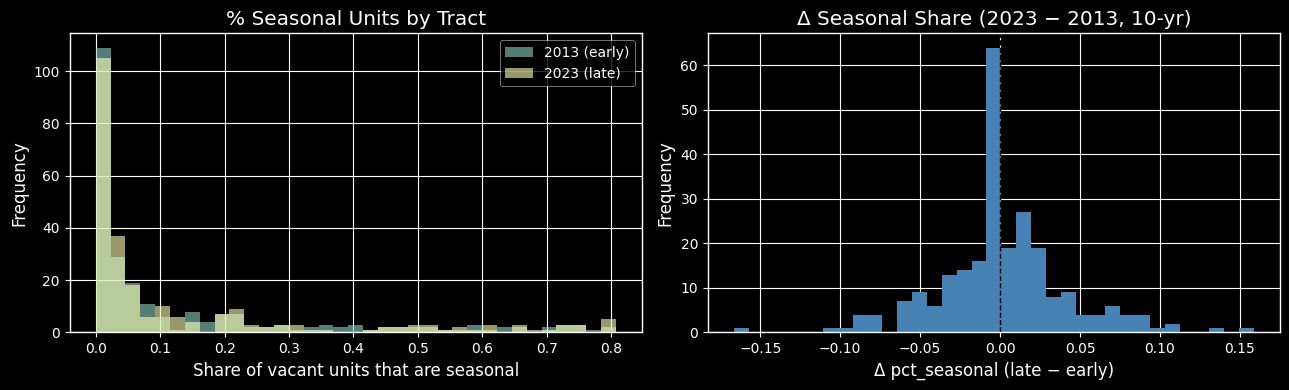

In [10]:
# --- Verification ---
n = len(parcels)
has_geoid  = parcels["GEOID"].notna().sum()
has_early  = parcels["pct_seasonal_early"].notna().sum()
has_late   = parcels["pct_seasonal_late"].notna().sum()
has_both   = parcels[["pct_seasonal_early", "pct_seasonal_late"]].notna().all(axis=1).sum()

print(f"{'=== Join Coverage ==='}")
print(f"Total rows (all years):          {n:>10,}")
print(f"With tract GEOID:                {has_geoid:>10,}  ({has_geoid/n:.1%})")
print(f"With early ACS ({YEAR_EARLY}):        {has_early:>10,}  ({has_early/n:.1%})")
print(f"With late ACS  ({YEAR_LATE}):        {has_late:>10,}  ({has_late/n:.1%})")
print(f"With both (complete join):       {has_both:>10,}  ({has_both/n:.1%})")
print()

# GEOID coverage per county
print("=== Tract match rate by county ===")
print(
    parcels[parcels["mod_iv_year"] == 2023]
    .groupby("mod_iv_county_name")["GEOID"]
    .agg(total="count", matched=lambda x: x.notna().sum())
    .assign(pct=lambda d: (d["matched"] / d["total"]).map("{:.1%}".format))
    .to_string()
)
print()

# ACS tract-level stats (unique tracts only, not repeated across parcel-years)
tract_stats = (
    parcels.drop_duplicates("GEOID")
    [["pct_seasonal_early", "pct_seasonal_late", "delta_pct_seasonal"]]
    .dropna()
)
print(f"=== Seasonal share distribution ({len(tract_stats)} complete tracts, {YEAR_DIFF}-yr window) ===")
print(tract_stats.describe().round(3))
print()
print(f"Tracts where seasonal share grew:   {(tract_stats['delta_pct_seasonal'] > 0).sum()}")
print(f"Tracts where seasonal share fell:   {(tract_stats['delta_pct_seasonal'] < 0).sum()}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

tract_stats[["pct_seasonal_early", "pct_seasonal_late"]].plot.hist(
    bins=35, alpha=0.6, ax=axes[0],
    title="% Seasonal Units by Tract"
)
axes[0].set_xlabel("Share of vacant units that are seasonal")
axes[0].legend([f"{YEAR_EARLY} (early)", f"{YEAR_LATE} (late)"])

tract_stats["delta_pct_seasonal"].plot.hist(
    bins=35, ax=axes[1], color="steelblue",
    title=f"Δ Seasonal Share ({YEAR_LATE} − {YEAR_EARLY}, {YEAR_DIFF}-yr)"
)
axes[1].axvline(0, color="black", lw=1, ls="--")
axes[1].set_xlabel("Δ pct_seasonal (late − early)")

plt.tight_layout()
plt.show()